# Определение возраста покупателей

## Описание

### Описание проекта
Сетевой супермаркет «Хлеб-Соль» внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:
анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;
контролировать добросовестность кассиров при продаже алкоголя.


Постройте модель, которая по фотографии определит приблизительный возраст человека. В вашем распоряжении набор фотографий людей с указанием возраста.




### Описание данных
Данные взяты с сайта ChaLearn Looking at People. Они находятся в папке /datasets/faces/.
В вашем распоряжении одна папка со всеми изображениями (/final_files) и CSV-файл labels.csv с двумя колонками: file_name и real_age.
Извлечь данные из папки вам поможет новый метод ImageDataGenerator —flow_from_dataframe(dataframe, directory, ...).

### Инструкция по выполнению проекта

Проведите исследовательский анализ набора фотографий.
Подготовьте данные к обучению.
Обучите нейронную сеть и рассчитайте её качество.

## Исследовательский анализ данных

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from matplotlib import rcParams, rcParamsDefault
from PIL import Image
from tensorflow import keras
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.layers import Conv2D, Flatten, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import metrics


import os
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
RANDOM_SEED = 89

In [3]:
cllap = pd.read_csv('/datasets/faces/labels.csv')

https://chalearnlap.cvc.uab.es/dataset/26/description/

Цитирование:

Если вы используете этот набор данных, пожалуйста, укажите:

@inproceedings{agustsson2017appareal,
  title={Apparent and real age estimation in still images with deep residual regressors on APPA-REAL database.},
  author={E Agustsson, R Timofte, S Escalera, X Baro, I Guyon, R Rothe.},
  booktitle={12th IEEE International Conference and Workshops on Automatic Face and Gesture Recognition (FG), 2017},
  year={2017},
  organization={IEEE}
}

In [4]:
cllap.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


In [5]:
print(cllap.head())

    file_name  real_age
0  000000.jpg         4
1  000001.jpg        18
2  000002.jpg        80
3  000003.jpg        50
4  000004.jpg        17


Пока все правильно.

In [6]:
sorted_ages = sorted(cllap['real_age'].unique())
print(sorted_ages)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 93, 94, 95, 96, 97, 100]


Промежуточный вывод.

Данные по описанию полностью совпадают. И даже больше. Они совпадают с тем описанием, что было найдено мной на ChaLearn Looking at People. В дальнейшем я "прикреплю" названия файлов к самим файлам, но только после статистического анализа оных.
Возраст От 1 до 100

### Статистический анализ данных

In [7]:
age_counts = cllap['real_age'].value_counts().sort_index()


(array([-20.,   0.,  20.,  40.,  60.,  80., 100., 120.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

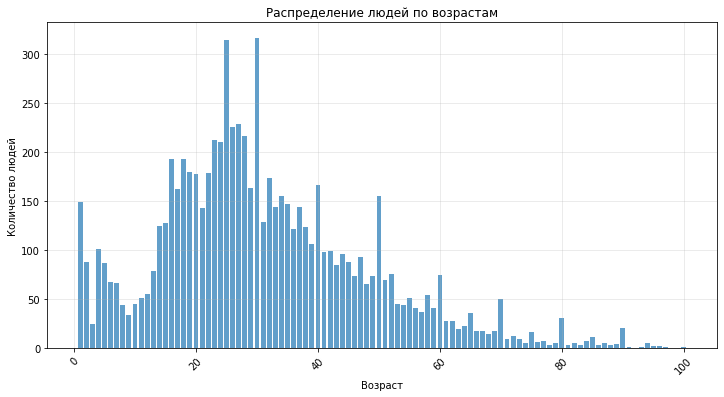

In [8]:
plt.figure(figsize=(12, 6))

plt.subplot()
plt.bar(age_counts.index, age_counts.values, alpha=0.7)
plt.title('Распределение людей по возрастам')
plt.xlabel('Возраст')
plt.ylabel('Количество людей')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

Помимо искажения нормального Пуасонского распределения, мы наблюдаем пики в некоторых местах.

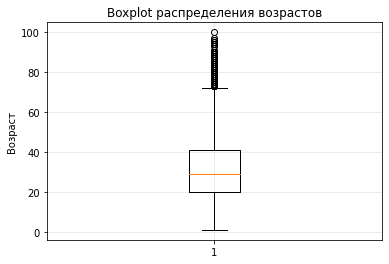

In [9]:
plt.subplot()
plt.boxplot(cllap['real_age'])
plt.title('Boxplot распределения возрастов')
plt.ylabel('Возраст')
plt.grid(True, alpha=0.3)





Неплохая линия выбросов после 70 лет. Она обусловлена тем, что сиех возрастов довольно мало.

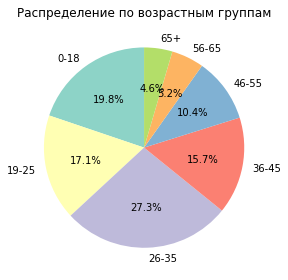

In [10]:
plt.subplot()


cllap['age_group'] = pd.cut(cllap['real_age'],
                         bins=[0, 18, 25, 35, 45, 55, 65, 100],
                         labels=['0-18', '19-25', '26-35', '36-45', '46-55', '56-65', '65+'],
                         right=False)

age_group_counts = cllap['age_group'].value_counts().sort_index()

plt.pie(age_group_counts.values, labels=age_group_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=sns.color_palette('Set3'))
plt.title('Распределение по возрастным группам')

plt.tight_layout()
plt.show()

In [11]:
print(f"Общее количество людей: {len(cllap):,}")
print(f"Средний возраст: {cllap['real_age'].mean():.1f} лет")
print(f"Медиана возраста: {cllap['real_age'].median()} лет")
print(f"Стандартное отклонение: {cllap['real_age'].std():.1f} лет")

Общее количество людей: 7,591
Средний возраст: 31.2 лет
Медиана возраста: 29.0 лет
Стандартное отклонение: 17.1 лет


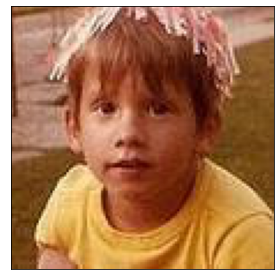

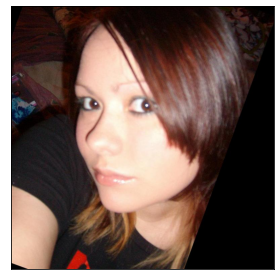

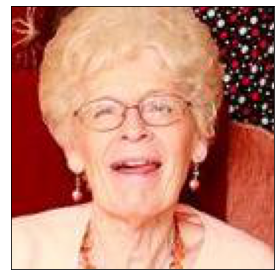

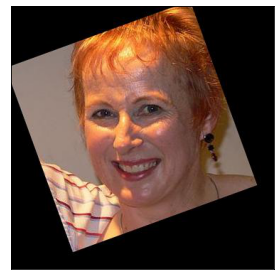

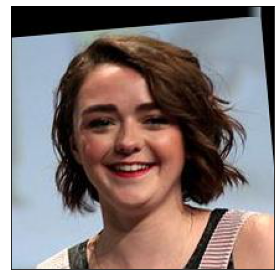

In [17]:
for i in range(5):
    file_path = f'/datasets/faces/final_files/00000{i}.jpg'
    image = Image.open(file_path)
    plt.imshow(np.array(image))
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.show()

Хм. Фотографии. Разного качества.

Наблюдается интересная деталь. Все фото выровняны так, что бы сделать лицо в профиль. Вертикально, как в паспорте. Это хорошо. Ведь только лица нам и нужны, а необрезанные рамки можно опустить.

Промежуточный вывод:
Нормального колокообразного распределения нет из-за большого количества детей, выбивающихся из статистики. А это в свою очередь делает из пожилых людей выбросы. Надо брать тогда было и побольше фото стариков старше 70 лет.
И кстати, 7591 человек в датасете. Теперь, на мой взгляд - это не очень большая выборка людей.
Сильный перекос в сторону молодых и средневозростных (если 30-летних можно считать таковыми)
И мало данных о людях после 55 лет

А еще данные не совсем соответствуют истине. Из-за пиков в круглых возростах имеет смысл предпологать определение и приписывание некоторых возрастов "на глаз". Авторы датасета слукавили в данном признаке, что так-же не играет нам на руку.

## Подготовка данных к обучению.


In [ ]:
cllap = pd.read_csv('/datasets/faces/labels.csv')

In [ ]:
cllap = '/datasets/faces/' #перезаписано
df_cllap = pd.read_csv(cllap + 'labels.csv')


In [ ]:
df_cllap.shape

А теперь я использую ImageDataGenerator
ImageDataGenerator —flow_from_dataframe(dataframe, directory, ...).

In [ ]:
datagen = ImageDataGenerator(rescale=1./255)

datagen_flow = datagen.flow_from_dataframe(
    dataframe=df_cllap,
    directory = cllap + 'final_files/',
    x_col='file_name',
    y_col='real_age',
    target_size=(224, 224),
    batch_size=32,
    class_mode='raw',
    seed=RANDOM_SEED)

Прекрасно

In [ ]:
# < Перенесите сюда исследовательский анализ данных >

## Обучение модели

Обучите нейронную сеть и рассчитайте её качество.

Перенесите сюда код обучения модели и её результат вывода на экран.


(Код в этом разделе запускается в отдельном GPU-тренажёре, поэтому оформлен не как ячейка с кодом, а как код в текстовой ячейке)

```python

# < скопируйте код сюда >
def load_data(path, subset, batch_size=32, augment=False):
    labels = pd.read_csv(os.path.join(path, 'labels.csv'))
    
    if augment:
        datagen = ImageDataGenerator(
            rescale=1./255,
            validation_split=0.25,
            horizontal_flip=True,
            brightness_range=(0.8, 1.)
        )
    else:
        datagen = ImageDataGenerator(
            rescale=1./255,
            validation_split=0.25
        )
    
    data_flow = datagen.flow_from_dataframe(
        dataframe=labels,
        directory=os.path.join(path, 'final_files/'),
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=batch_size,
        class_mode='raw',
        subset=subset,
        seed=12345
    )
    
    return data_flow

def create_model(input_shape, learning_rate=0.0001):
    backbone = ResNet50(
        input_shape=input_shape,
        weights='imagenet', 
        include_top=False
    )

    model = Sequential([
        backbone,
        GlobalAveragePooling2D(),
        Dense(1, activation='relu')
    ])
    
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss='mean_squared_error',
        metrics=['mae']
    )
    
    return model

def train_model(model, train_data, test_data, epochs=20, patience=5):
    early_stopping = EarlyStopping(
        monitor='val_mae', 
        patience=patience, 
        restore_best_weights=True
    )
    
    history = model.fit(
        train_data,
        validation_data=test_data,
        epochs=epochs,
        verbose=2,
        callbacks=[early_stopping]
    )
    
    return model, history


if __name__ == "__main__":
    DATA_PATH = '/datasets/faces/'
    BATCH_SIZE = 32
    EPOCHS = 25
    INPUT_SHAPE = (224, 224, 3)

    train_data = load_data(DATA_PATH, 'training', BATCH_SIZE, augment=True)
    test_data = load_data(DATA_PATH, 'validation', BATCH_SIZE, augment=False)

    model = create_model(INPUT_SHAPE)
    
    trained_model, history = train_model(model, train_data, test_data, EPOCHS)

```

```

# < скопируйте результат вывода на экран сюда >
# < длинные строки со скачиванием модели можно удалить >

```

Epoch 1/25
18/18 - 62s - 3s/step - loss: 863.7354 - mae: 24.6205 - val_loss: 1140.3431 - val_mae: 29.1398
Epoch 2/25
18/18 - 44s - 2s/step - loss: 258.2128 - mae: 11.8235 - val_loss: 1105.7062 - val_mae: 28.5388
Epoch 3/25
18/18 - 41s - 2s/step - loss: 109.1911 - mae: 7.3501 - val_loss: 1056.1100 - val_mae: 27.6820
Epoch 4/25
18/18 - 41s - 2s/step - loss: 85.3631 - mae: 6.2930 - val_loss: 1021.2930 - val_mae: 27.0839
Epoch 5/25
18/18 - 41s - 2s/step - loss: 63.1204 - mae: 5.4974 - val_loss: 987.2284 - val_mae: 26.5059
Epoch 6/25
18/18 - 41s - 2s/step - loss: 40.3607 - mae: 4.4817 - val_loss: 963.6793 - val_mae: 26.0984
Epoch 7/25
18/18 - 43s - 2s/step - loss: 33.4870 - mae: 4.3226 - val_loss: 952.3082 - val_mae: 25.8988
Epoch 8/25
18/18 - 45s - 2s/step - loss: 25.9214 - mae: 3.7371 - val_loss: 943.3407 - val_mae: 25.7388
Epoch 9/25
18/18 - 46s - 3s/step - loss: 23.2288 - mae: 3.5259 - val_loss: 924.8265 - val_mae: 25.4098
Epoch 10/25
18/18 - 48s - 3s/step - loss: 14.2224 - mae: 2.8455 - val_loss: 931.8641 - val_mae: 25.5340
Epoch 11/25
18/18 - 49s - 3s/step - loss: 18.0854 - mae: 3.2509 - val_loss: 922.6707 - val_mae: 25.3726
Epoch 12/25
18/18 - 48s - 3s/step - loss: 19.2673 - mae: 3.2631 - val_loss: 918.1250 - val_mae: 25.2955
Epoch 13/25
18/18 - 49s - 3s/step - loss: 17.9143 - mae: 3.0969 - val_loss: 909.1532 - val_mae: 25.1424
Epoch 14/25
18/18 - 49s - 3s/step - loss: 15.0792 - mae: 2.9896 - val_loss: 905.0233 - val_mae: 25.0719
Epoch 15/25
18/18 - 50s - 3s/step - loss: 16.8071 - mae: 3.2456 - val_loss: 892.7197 - val_mae: 24.8606
Epoch 16/25
18/18 - 50s - 3s/step - loss: 12.5252 - mae: 2.8137 - val_loss: 898.2687 - val_mae: 24.9591
Epoch 17/25
18/18 - 49s - 3s/step - loss: 11.9309 - mae: 2.6404 - val_loss: 898.4118 - val_mae: 24.9608
Epoch 18/25
18/18 - 50s - 3s/step - loss: 12.9852 - mae: 2.7029 - val_loss: 883.9731 - val_mae: 24.7145
Epoch 19/25
18/18 - 52s - 3s/step - loss: 19.7241 - mae: 3.5788 - val_loss: 880.4153 - val_mae: 24.6598
Epoch 20/25
18/18 - 50s - 3s/step - loss: 13.0287 - mae: 2.7719 - val_loss: 864.2083 - val_mae: 24.3862
Epoch 21/25
18/18 - 50s - 3s/step - loss: 17.0577 - mae: 3.1851 - val_loss: 810.3101 - val_mae: 23.4612
Epoch 22/25
18/18 - 50s - 3s/step - loss: 18.0732 - mae: 3.4061 - val_loss: 821.5358 - val_mae: 23.6497
Epoch 23/25
18/18 - 52s - 3s/step - loss: 15.9574 - mae: 2.9868 - val_loss: 792.0507 - val_mae: 23.1304
Epoch 24/25
18/18 - 52s - 3s/step - loss: 14.3745 - mae: 2.9955 - val_loss: 799.9097 - val_mae: 23.2728
Epoch 25/25
18/18 - 52s - 3s/step - loss: 10.0760 - mae: 2.3799 - val_loss: 768.0370 - val_mae: 22.6848

## Анализ обученной модели


Анализ модели
В финальную тетрадь Jupyter Notebook скопируйте исследовательский анализ данных, код и вывод модели. Затем проанализируйте результат обучения модели.


### Задание 1
Подготовьте отчёт по исследованию данных и обучению модели.

Объем данных: 7,591 изображений с подписанным возрастом. Ничего не перепутано и не поломано. Все файлы валидны.

Анализ результатов обучения модели и отчет по исследованию
Основные метрики:
Loss: 863.7
MAE: 22.68 лет

train (10.08) очень разнится с valid (768.04)

и val_loss вообще себя плохо показывает по сравнению с тренировочной

Модель вроде работает и предсказывает возраст, но требует значительных доработок для снижения переобучения. Итоговый результат сопряжен со множеством факторов, которые я предсказал еще в статистическом анализе данных.


Напишите выводы здесь

На оригинальном сайте сказано:

The APPA-REAL database contains 7,591 images with associated real and apparent age labels. The total number of apparent votes is around 250,000. On average we have around 38 votes per each image and this makes the average apparent age very stable (0.3 standard error of the mean).

Эта информация оказалась верна.

Насчет анализа: проблема в распределении выборки-данных. Мало стариков. Если бы не это, то модель была бы идеальна. А конкретнее:Сильный перекос в сторону молодых и средневозростных и мало данных о людях после 55 лет. Из-за пиков в круглых возростах имеет смысл предпологать определение и приписывание некоторых возрастов "на глаз"

Теперь о самой модели:
Она работает. Разумеется, через этот тренажер ее не запустить, поэтому я выложил ее выводы отдельно.
Интерпретируются они не особо хорошо. Модель склонна к ошибкам с великозрастными людьми.

НО на мой взгляд - это не критично при наших целях.

"анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы; контролировать добросовестность кассиров при продаже алкоголя"

То есть, если покупатель уже взрослый, то вопрос о продаже алкоголя даже не поднимается. А интерес зависит уже от вкуса конкретных предпочтений покупателя.

То есть моя модель в этом случае идеальна. 